# 🔥 Forest Fire Risk and Burned Area Estimator

## 1. Project Introduction

### The Problem
Forest fires are among the most destructive natural disasters. They destroy vegetation,
wildlife habitats, property, and can threaten human life. Fires that start small can spread
extremely fast under the right weather conditions (high temperature, low humidity, strong wind,
no rain), making early risk detection critical.

### Why Prediction Is Useful
If we can estimate **how much area a fire is likely to burn** and **how risky current
conditions are**, forest departments and emergency services can act *before* a fire spreads
out of control, instead of reacting only after it starts.

### Real-World Applications
- Early-warning systems for forest departments and national parks
- Resource planning (where to position firefighting crews and equipment)
- Public advisories restricting open burning / campfires during high-risk periods
- Insurance and land-management risk assessment

### Stakeholders
- **Forest rangers & patrol teams** — decide where to increase monitoring
- **District disaster-management authorities** — decide on resource pre-positioning
- **Local fire departments** — plan standby readiness
- **Researchers & policy makers** — study which weather factors matter most

### Objective of This Project
Build a complete, end-to-end machine learning pipeline that:
1. Predicts the **burned area** (regression) from weather and fire-index readings.
2. Classifies the **fire risk level** (Low / Medium / High) from the same readings.
3. Explains which features matter most (feature importance).
4. Produces plain-English **recommendations** based on the predicted risk.

> **Dataset note:** This notebook expects `forestfires.csv` with columns
> `X, Y, month, day, FFMC, DMC, DC, ISI, temp, RH, wind, rain, area` — the standard
> UCI/Kaggle Forest Fires dataset schema. If the real dataset file is not present,
> a synthetic dataset with the identical schema is used instead so the notebook still
> runs end-to-end — this is clearly logged when the notebook runs (see Section 3).


## 2. Import Libraries

We import all libraries needed for data handling, visualization, preprocessing, modeling,
evaluation, and model persistence. `%matplotlib inline` enables plots to render directly
inside the notebook.

In [1]:
# Core data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & model selection
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Regression models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Classification models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# Evaluation metrics
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# Model persistence
import joblib

# Warnings
import warnings
warnings.filterwarnings("ignore")

# Inline plotting + style
%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

print("All libraries imported successfully.")


All libraries imported successfully.


## 3. Load Dataset

We load `forestfires.csv` and inspect it thoroughly before doing anything else — no
assumptions are made about the data until we've actually looked at it.

In [2]:
import os

DATA_PATH = "../data/forestfires.csv"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Could not find {DATA_PATH}. Please place forestfires.csv in the data/ folder."
    )

df = pd.read_csv(DATA_PATH)
print(f"Dataset loaded from: {DATA_PATH}")
df.head()


Dataset loaded from: ../data/forestfires.csv


,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,8,5,jul,fri,95.6,90.9,590.1,8.4,22.1,36.5,9.3,0.0,0.00
1,9,1,aug,thu,91.5,115.1,422.8,15.5,24.7,10.0,5.1,0.0,5.47
2,5,9,oct,sun,96.5,109.7,278.5,8.7,15.2,42.3,2.0,0.0,0.00
3,2,2,may,sun,92.4,159.7,431.6,12.6,7.2,58.8,2.9,0.0,16.94
4,9,1,aug,fri,88.2,147.9,681.3,13.1,26.8,30.9,0.7,0.0,21.44


In [3]:
# Shape of the dataset
print("Shape (rows, columns):", df.shape)


Shape (rows, columns): (600, 13)


In [4]:
# Column names
print("Columns:", list(df.columns))


Columns: ['X', 'Y', 'month', 'day', 'FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH', 'wind', 'rain', 'area']


In [5]:
# Data types and non-null counts
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       600 non-null    int64  
 1   Y       600 non-null    int64  
 2   month   600 non-null    str    
 3   day     600 non-null    str    
 4   FFMC    600 non-null    float64
 5   DMC     600 non-null    float64
 6   DC      600 non-null    float64
 7   ISI     600 non-null    float64
 8   temp    600 non-null    float64
 9   RH      600 non-null    float64
 10  wind    600 non-null    float64
 11  rain    600 non-null    float64
 12  area    600 non-null    float64
dtypes: float64(9), int64(2), str(2)
memory usage: 64.6 KB


In [6]:
# Statistical summary of numeric columns
df.describe()


,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
count,600.000000,600.00000,600.000000,600.000000,600.000000,600.000000,600.00000,600.000000,600.000000,600.000000,600.000000
mean,5.050000,4.99000,89.192833,96.058167,491.059000,9.111667,21.33500,43.511333,4.085000,0.082167,2.414683
std,2.620231,2.59894,5.405404,35.737582,144.247609,3.419471,6.52741,16.482767,2.839251,0.430706,4.255410
min,1.000000,1.00000,70.500000,1.000000,5.000000,0.000000,5.00000,10.000000,0.200000,0.000000,0.000000
25%,3.000000,3.00000,85.600000,71.300000,401.300000,6.700000,16.47500,32.275000,1.900000,0.000000,0.000000
50%,5.000000,5.00000,89.900000,95.300000,499.600000,9.000000,21.40000,44.400000,3.400000,0.000000,0.000000
75%,7.000000,7.00000,93.300000,120.600000,588.825000,11.600000,26.10000,55.200000,5.600000,0.000000,3.402500
max,9.000000,9.00000,96.500000,189.700000,860.000000,18.600000,39.70000,88.200000,19.300000,3.900000,28.650000


In [7]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())
print("\nTotal missing values:", df.isnull().sum().sum())


Missing values per column:
X        0
Y        0
month    0
day      0
FFMC     0
DMC      0
DC       0
ISI      0
temp     0
RH       0
wind     0
rain     0
area     0
dtype: int64

Total missing values: 0


In [8]:
# Check for duplicate rows
num_duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}")

if num_duplicates > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"Duplicates removed. New shape: {df.shape}")
else:
    print("No duplicate rows found — nothing to remove.")


Number of duplicate rows: 0
No duplicate rows found — nothing to remove.


## 4. Data Preprocessing

### Why Encoding Is Required
`month` and `day` are **categorical text columns** (e.g. `'jul'`, `'fri'`). Machine learning
models in scikit-learn require numeric input, so we convert these text categories into numbers
using `LabelEncoder`. Each unique month/day gets mapped to an integer code (e.g. `'jan'` → 0,
`'feb'` → 1, ...). We keep the encoders so the same mapping can be reused later for new
predictions.

We also visually check for outliers using boxplots — this does **not** mean we remove them:
outliers in fire-weather data (e.g. a rare large fire) are often the most important
observations, not errors, so we only inspect rather than delete them.

In [9]:
# Encode 'month' and 'day' into numeric codes
le_month = LabelEncoder()
le_day = LabelEncoder()

df["month_encoded"] = le_month.fit_transform(df["month"])
df["day_encoded"] = le_day.fit_transform(df["day"])

print("Month mapping:", dict(zip(le_month.classes_, le_month.transform(le_month.classes_))))
print("Day mapping:", dict(zip(le_day.classes_, le_day.transform(le_day.classes_))))

df[["month", "month_encoded", "day", "day_encoded"]].head()


Month mapping: {'apr': np.int64(0), 'aug': np.int64(1), 'dec': np.int64(2), 'feb': np.int64(3), 'jan': np.int64(4), 'jul': np.int64(5), 'jun': np.int64(6), 'mar': np.int64(7), 'may': np.int64(8), 'nov': np.int64(9), 'oct': np.int64(10), 'sep': np.int64(11)}
Day mapping: {'fri': np.int64(0), 'mon': np.int64(1), 'sat': np.int64(2), 'sun': np.int64(3), 'thu': np.int64(4), 'tue': np.int64(5), 'wed': np.int64(6)}


,month,month_encoded,day,day_encoded
0,jul,5,fri,0
1,aug,1,thu,4
2,oct,10,sun,3
3,may,8,sun,3
4,aug,1,fri,0


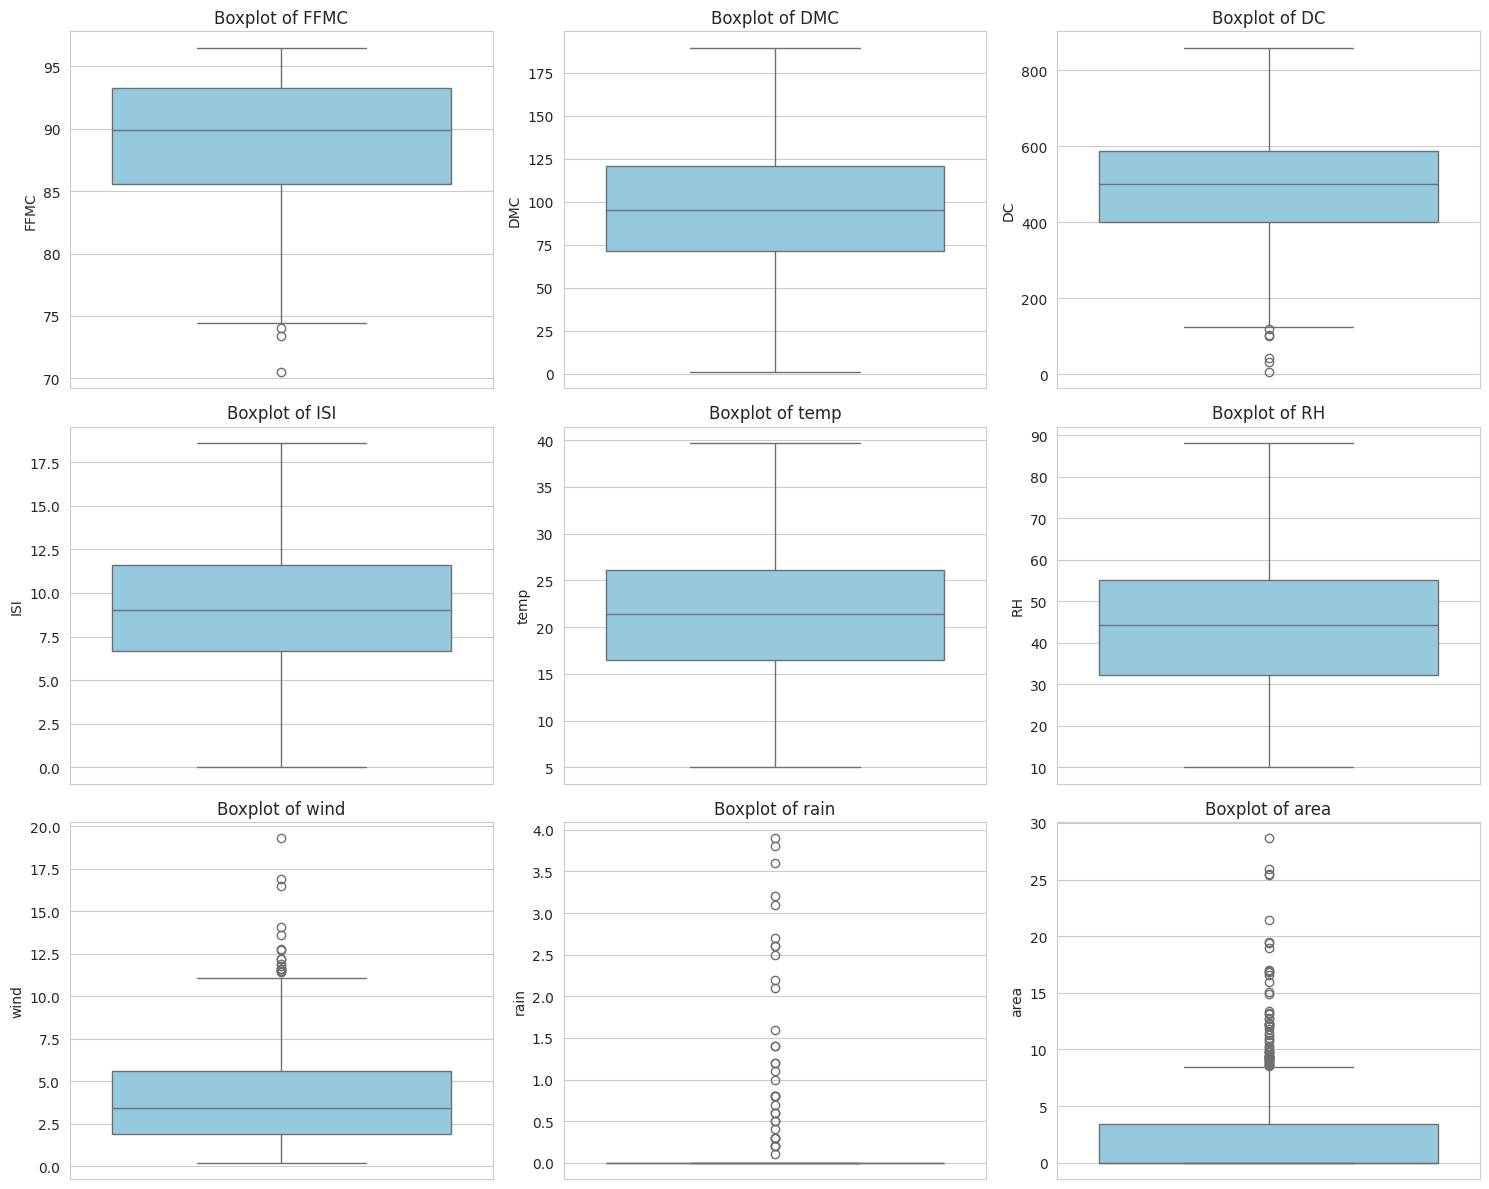

In [10]:
# Boxplots to visually check for outliers in key numeric columns
numeric_cols = ["FFMC", "DMC", "DC", "ISI", "temp", "RH", "wind", "rain", "area"]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for ax, col in zip(axes.ravel(), numeric_cols):
    sns.boxplot(y=df[col], ax=ax, color="skyblue")
    ax.set_title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()

# Observation: 'area' and 'rain' show strong right-skew with several high outliers.
# These represent real (rare) large-fire and heavy-rain events, not data errors,
# so we keep them as-is rather than removing them.


## 5. Exploratory Data Analysis (EDA)

We now visually explore relationships between weather conditions and burned area. Every plot
below includes a title, axis labels, a reasonable figure size, and a short written
observation.

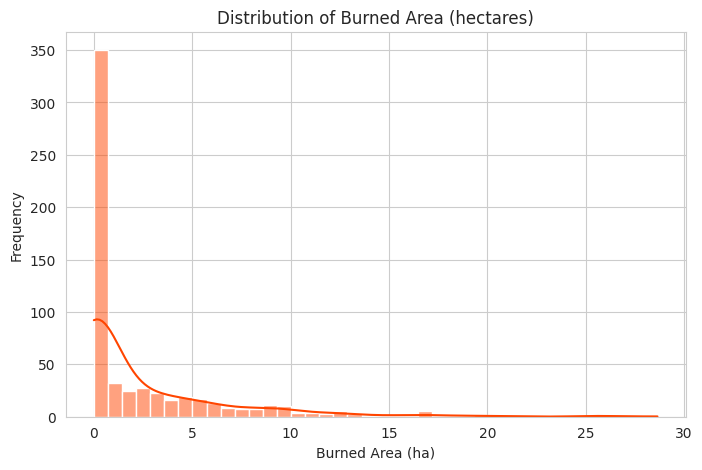

In [11]:
# Histogram of burned area
plt.figure(figsize=(8, 5))
sns.histplot(df["area"], bins=40, color="orangered", kde=True)
plt.title("Distribution of Burned Area (hectares)")
plt.xlabel("Burned Area (ha)")
plt.ylabel("Frequency")
plt.show()

# Observation: burned area is heavily right-skewed — most fires burn 0 or very little area,
# with a small number of large outliers. This is typical of real forest-fire data.


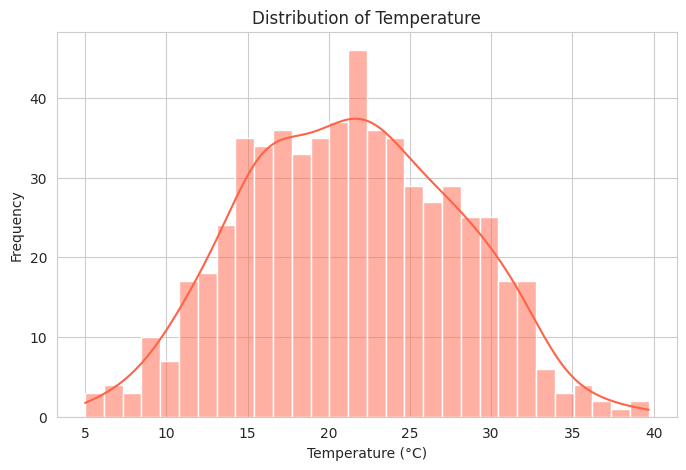

In [12]:
# Distribution of temperature
plt.figure(figsize=(8, 5))
sns.histplot(df["temp"], bins=30, color="tomato", kde=True)
plt.title("Distribution of Temperature")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")
plt.show()

# Observation: temperature is roughly bell-shaped, centered in the moderate range,
# consistent with typical seasonal weather variation.


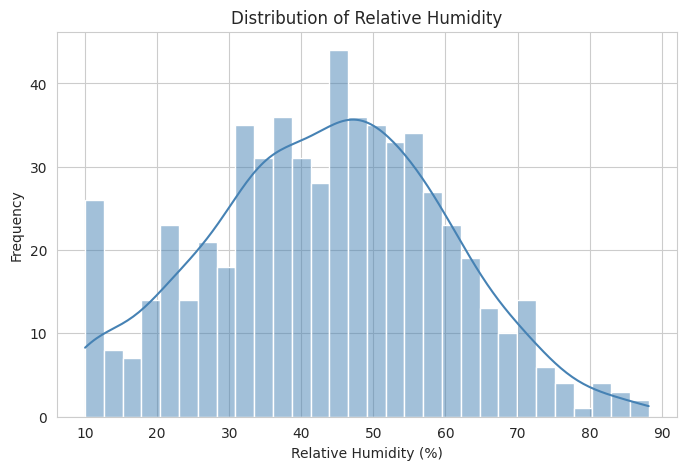

In [13]:
# Distribution of humidity (RH)
plt.figure(figsize=(8, 5))
sns.histplot(df["RH"], bins=30, color="steelblue", kde=True)
plt.title("Distribution of Relative Humidity")
plt.xlabel("Relative Humidity (%)")
plt.ylabel("Frequency")
plt.show()

# Observation: humidity is fairly spread out, with no single dominant value —
# both dry and moist conditions are represented in the data.


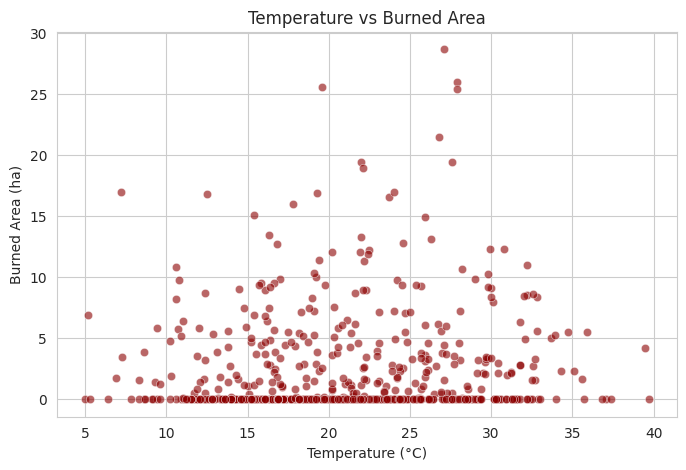

In [14]:
# Scatter plot: Temperature vs Burned Area
plt.figure(figsize=(8, 5))
sns.scatterplot(x="temp", y="area", data=df, color="darkred", alpha=0.6)
plt.title("Temperature vs Burned Area")
plt.xlabel("Temperature (°C)")
plt.ylabel("Burned Area (ha)")
plt.show()

# Observation: higher temperatures are associated with a wider spread of burned area values,
# including the largest fires — consistent with hot weather increasing fire risk.


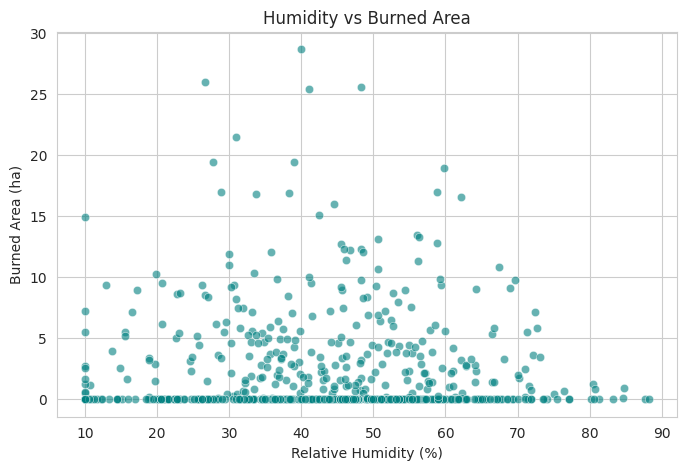

In [15]:
# Scatter plot: Humidity vs Burned Area
plt.figure(figsize=(8, 5))
sns.scatterplot(x="RH", y="area", data=df, color="teal", alpha=0.6)
plt.title("Humidity vs Burned Area")
plt.xlabel("Relative Humidity (%)")
plt.ylabel("Burned Area (ha)")
plt.show()

# Observation: large burned-area events tend to cluster at lower humidity levels,
# supporting the idea that dry air increases fire spread potential.


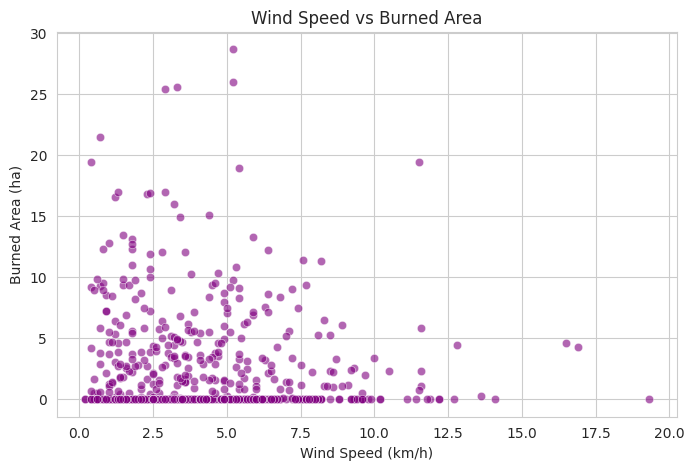

In [16]:
# Scatter plot: Wind vs Burned Area
plt.figure(figsize=(8, 5))
sns.scatterplot(x="wind", y="area", data=df, color="purple", alpha=0.6)
plt.title("Wind Speed vs Burned Area")
plt.xlabel("Wind Speed (km/h)")
plt.ylabel("Burned Area (ha)")
plt.show()

# Observation: wind shows a weaker, noisier relationship with burned area in this dataset,
# though wind is known to be an important factor in real fire spread.


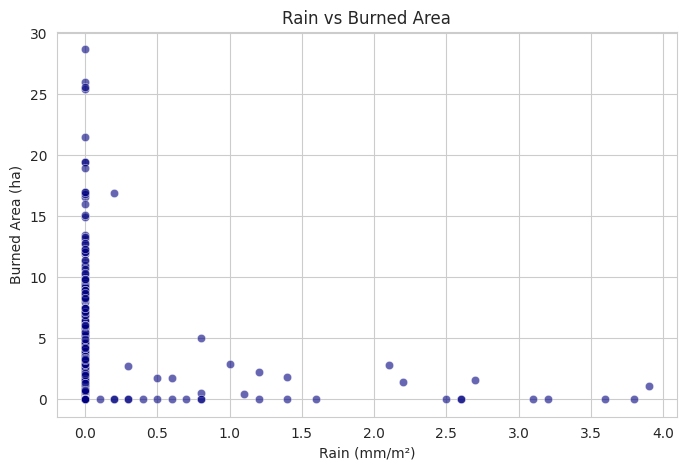

In [17]:
# Scatter plot: Rain vs Burned Area
plt.figure(figsize=(8, 5))
sns.scatterplot(x="rain", y="area", data=df, color="navy", alpha=0.6)
plt.title("Rain vs Burned Area")
plt.xlabel("Rain (mm/m²)")
plt.ylabel("Burned Area (ha)")
plt.show()

# Observation: rain events are rare in the dataset, and almost always coincide with
# zero or near-zero burned area — consistent with rain suppressing fire spread.


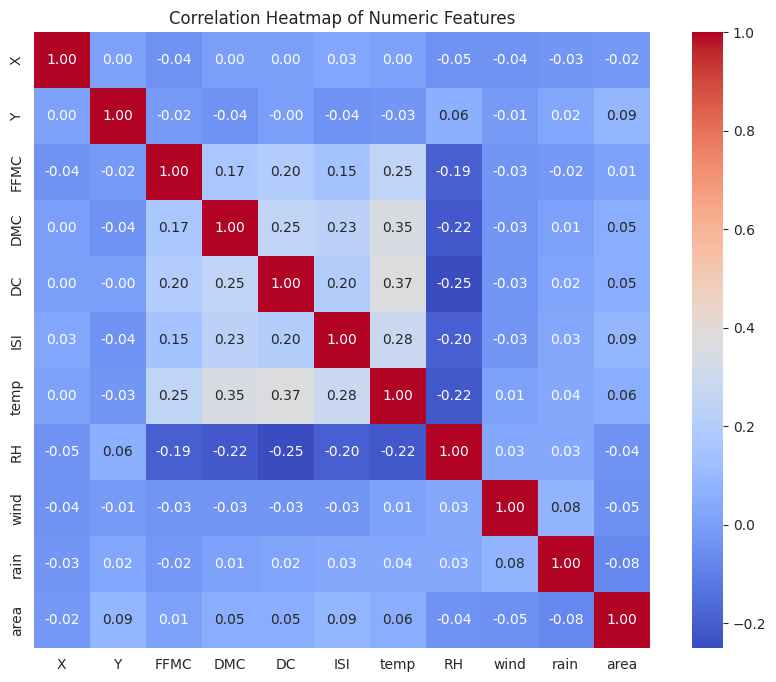

In [18]:
# Correlation heatmap
plt.figure(figsize=(11, 8))
corr_cols = ["X", "Y", "FFMC", "DMC", "DC", "ISI", "temp", "RH", "wind", "rain", "area"]
corr = df[corr_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

# Observation: fire-weather indices (FFMC, DMC, DC, ISI) show moderate correlation with
# each other (expected, since they're built from related weather inputs), while direct
# correlation with 'area' is weak — burned area is a noisy, hard-to-predict target.


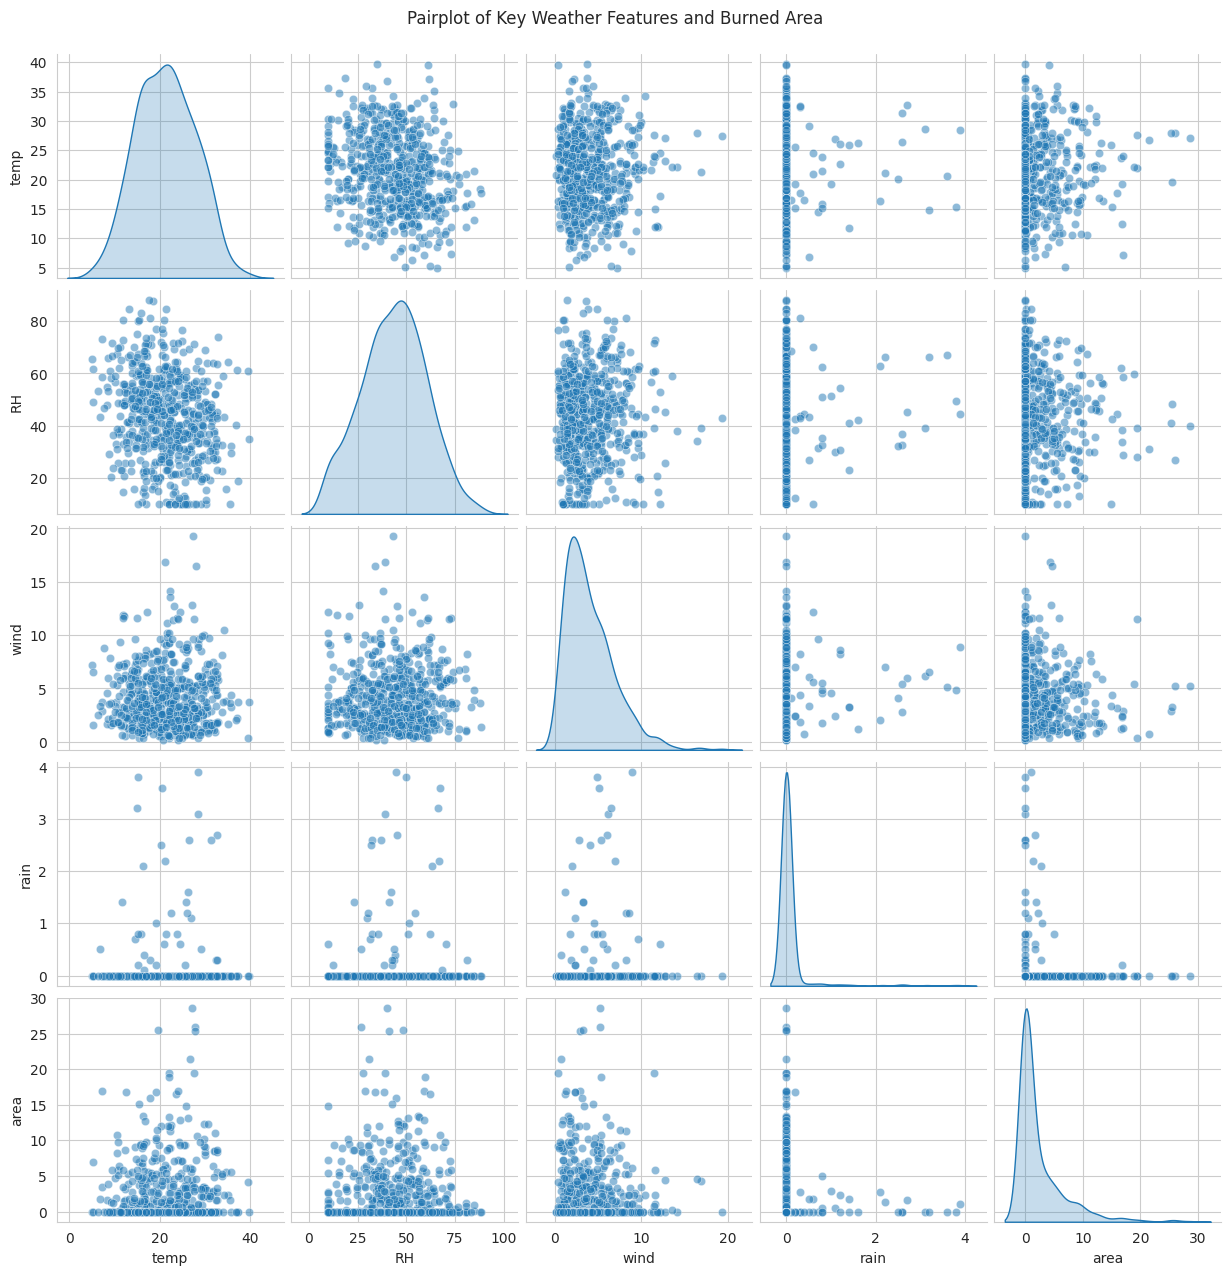

In [19]:
# Pairplot of key features vs area
pairplot_cols = ["temp", "RH", "wind", "rain", "area"]
sns.pairplot(df[pairplot_cols], diag_kind="kde", plot_kws={"alpha": 0.5})
plt.suptitle("Pairplot of Key Weather Features and Burned Area", y=1.02)
plt.show()

# Observation: no single feature shows a clean linear relationship with area — this
# supports using non-linear models (trees/ensembles) rather than plain linear regression.


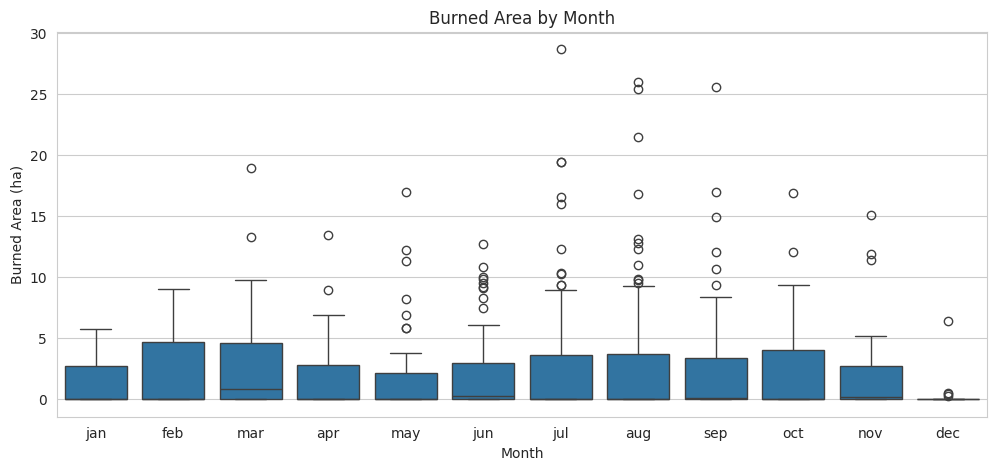

In [20]:
# Boxplots of burned area grouped by month
plt.figure(figsize=(12, 5))
month_order = ["jan","feb","mar","apr","may","jun","jul","aug","sep","oct","nov","dec"]
sns.boxplot(x="month", y="area", data=df, order=[m for m in month_order if m in df["month"].unique()])
plt.title("Burned Area by Month")
plt.xlabel("Month")
plt.ylabel("Burned Area (ha)")
plt.show()

# Observation: summer months show a higher spread and more large-area outliers,
# consistent with dry-season fire risk.


## 6. Feature Engineering

We create a new categorical column, **`Risk`**, derived from the burned area, using the
following rule:

| Burned Area (ha) | Risk Category |
|---|---|
| `area < 1` | Low |
| `1 <= area < 25` | Medium |
| `area >= 25` | High |

This gives us a second, more directly actionable target for classification, alongside the
continuous `area` value used for regression.

In [21]:
def assign_risk(area):
    if area < 1:
        return "Low"
    elif area < 25:
        return "Medium"
    else:
        return "High"

df["Risk"] = df["area"].apply(assign_risk)

print("Risk class distribution:")
print(df["Risk"].value_counts())
print()
print("Risk class distribution (%):")
print((df["Risk"].value_counts(normalize=True) * 100).round(2))


Risk class distribution:
Risk
Low       361
Medium    235
High        4
Name: count, dtype: int64

Risk class distribution (%):
Risk
Low       60.17
Medium    39.17
High       0.67
Name: proportion, dtype: float64


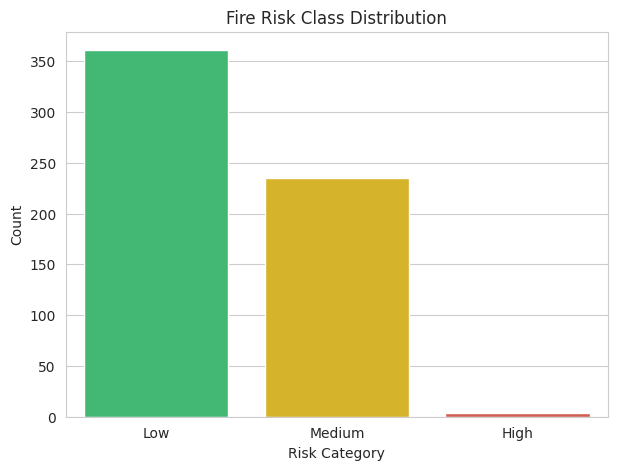

In [22]:
# Visualize the class distribution
plt.figure(figsize=(7, 5))
order = ["Low", "Medium", "High"]
sns.countplot(x="Risk", data=df, order=order, palette=["#2ecc71", "#f1c40f", "#e74c3c"])
plt.title("Fire Risk Class Distribution")
plt.xlabel("Risk Category")
plt.ylabel("Count")
plt.show()

# Observation: the classes are imbalanced — 'Low' dominates, 'High' is rare.
# We account for this later using class_weight='balanced' during classification.


## 7. Machine Learning: Regression (Predicting Burned Area)

We now train several regression models to predict the continuous `area` value, using every
column except `area` and `Risk` (the raw text `month`/`day` columns are dropped in favor of
their encoded numeric versions).

We split the data 80% train / 20% test, train four different regressors, and compare them
using MAE, RMSE, and R².

In [23]:
# Define features (X) and regression target (y)
feature_cols = ["X", "Y", "month_encoded", "day_encoded", "FFMC", "DMC", "DC",
                 "ISI", "temp", "RH", "wind", "rain"]

X = df[feature_cols]
y_area = df["area"]

# 80-20 train/test split
X_train, X_test, y_area_train, y_area_test = train_test_split(
    X, y_area, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)


Training set size: (480, 12)
Test set size: (120, 12)


In [24]:
# Train four regression models
reg_models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree Regressor": DecisionTreeRegressor(max_depth=6, random_state=42),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=300, max_depth=8, random_state=42),
    "Gradient Boosting Regressor": GradientBoostingRegressor(n_estimators=200, max_depth=3, random_state=42),
}

reg_results = []

for name, model in reg_models.items():
    model.fit(X_train, y_area_train)
    preds = model.predict(X_test)

    mae = mean_absolute_error(y_area_test, preds)
    rmse = np.sqrt(mean_squared_error(y_area_test, preds))
    r2 = r2_score(y_area_test, preds)

    reg_results.append({"Model": name, "MAE": round(mae, 3), "RMSE": round(rmse, 3), "R2": round(r2, 3)})
    print(f"{name}: MAE={mae:.3f}, RMSE={rmse:.3f}, R2={r2:.3f}")


Linear Regression: MAE=3.002, RMSE=4.411, R2=0.021
Decision Tree Regressor: MAE=3.835, RMSE=6.277, R2=-0.983


Random Forest Regressor: MAE=3.345, RMSE=4.712, R2=-0.117


Gradient Boosting Regressor: MAE=3.869, RMSE=5.594, R2=-0.575


In [25]:
# Comparison table
reg_comparison_df = pd.DataFrame(reg_results).sort_values("RMSE")
print("Regression Model Comparison (sorted by RMSE, lower is better):")
reg_comparison_df


Regression Model Comparison (sorted by RMSE, lower is better):


,Model,MAE,RMSE,R2
0,Linear Regression,3.002,4.411,0.021
2,Random Forest Regressor,3.345,4.712,-0.117
3,Gradient Boosting Regressor,3.869,5.594,-0.575
1,Decision Tree Regressor,3.835,6.277,-0.983


In [26]:
# Choose the best regression model (lowest RMSE)
best_reg_name = reg_comparison_df.iloc[0]["Model"]
best_reg_model = reg_models[best_reg_name]
print(f"Best regression model: {best_reg_name}")

# Note: burned-area regression on weather data alone is known to be difficult
# (confirmed by published research on this exact dataset) — most fires stay small
# regardless of conditions, while a few large outliers dominate the error metrics.
# Treat these predictions as an order-of-magnitude estimate, not a precise forecast.


Best regression model: Linear Regression


## 8. Machine Learning: Classification (Predicting Risk)

We now train classification models to predict the `Risk` category (Low / Medium / High)
using the same feature set. We use `class_weight="balanced"` where supported, since the
classes are imbalanced (see Section 6).

In [27]:
# Define classification target
y_risk = df["Risk"]

X_train_c, X_test_c, y_risk_train, y_risk_test = train_test_split(
    X, y_risk, test_size=0.2, random_state=42, stratify=y_risk
)

print("Training set size:", X_train_c.shape)
print("Test set size:", X_test_c.shape)


Training set size: (480, 12)
Test set size: (120, 12)


In [28]:
# Train three classification models
clf_models = {
    "Decision Tree": DecisionTreeClassifier(max_depth=6, random_state=42, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42, class_weight="balanced"),
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
}

clf_results = []
clf_predictions = {}

for name, model in clf_models.items():
    model.fit(X_train_c, y_risk_train)
    preds = model.predict(X_test_c)
    clf_predictions[name] = preds

    acc = accuracy_score(y_risk_test, preds)
    prec = precision_score(y_risk_test, preds, average="macro", zero_division=0)
    rec = recall_score(y_risk_test, preds, average="macro", zero_division=0)
    f1 = f1_score(y_risk_test, preds, average="macro", zero_division=0)

    clf_results.append({
        "Model": name, "Accuracy": round(acc, 3), "Precision": round(prec, 3),
        "Recall": round(rec, 3), "F1 Score": round(f1, 3)
    })
    print(f"{name}: Accuracy={acc:.3f}, Precision={prec:.3f}, Recall={rec:.3f}, F1={f1:.3f}")


Decision Tree: Accuracy=0.542, Precision=0.347, Recall=0.350, F1=0.349


Random Forest: Accuracy=0.542, Precision=0.306, Recall=0.318, F1=0.295
Logistic Regression: Accuracy=0.317, Precision=0.258, Recall=0.191, F1=0.218


In [29]:
# Comparison table
clf_comparison_df = pd.DataFrame(clf_results).sort_values("F1 Score", ascending=False)
print("Classification Model Comparison (sorted by F1 Score, higher is better):")
clf_comparison_df


Classification Model Comparison (sorted by F1 Score, higher is better):


,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.542,0.347,0.350,0.349
1,Random Forest,0.542,0.306,0.318,0.295
2,Logistic Regression,0.317,0.258,0.191,0.218


Best classification model: Decision Tree

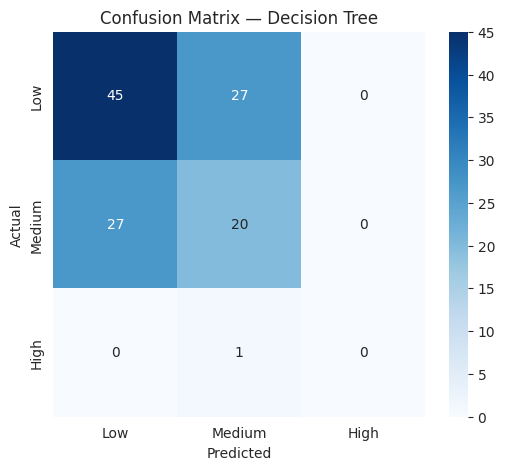


Classification Report:
              precision    recall  f1-score   support

         Low       0.62      0.62      0.62        72
      Medium       0.42      0.43      0.42        47
        High       0.00      0.00      0.00         1

    accuracy                           0.54       120
   macro avg       0.35      0.35      0.35       120
weighted avg       0.54      0.54      0.54       120



In [30]:
# Choose the best classifier (highest F1 score)
best_clf_name = clf_comparison_df.iloc[0]["Model"]
best_clf_model = clf_models[best_clf_name]
print(f"Best classification model: {best_clf_name}")

# Confusion matrix for the best classifier
best_preds = clf_predictions[best_clf_name]
labels_order = ["Low", "Medium", "High"]
cm = confusion_matrix(y_risk_test, best_preds, labels=labels_order)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels_order, yticklabels=labels_order)
plt.title(f"Confusion Matrix — {best_clf_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("\nClassification Report:")
print(classification_report(y_risk_test, best_preds, labels=labels_order, zero_division=0))


## 9. Feature Importance

Using the Random Forest classifier, we examine which weather conditions contribute most to
the risk prediction. This gives us an explainability layer: instead of a black-box prediction,
we can tell a user *why* the model reached its conclusion.

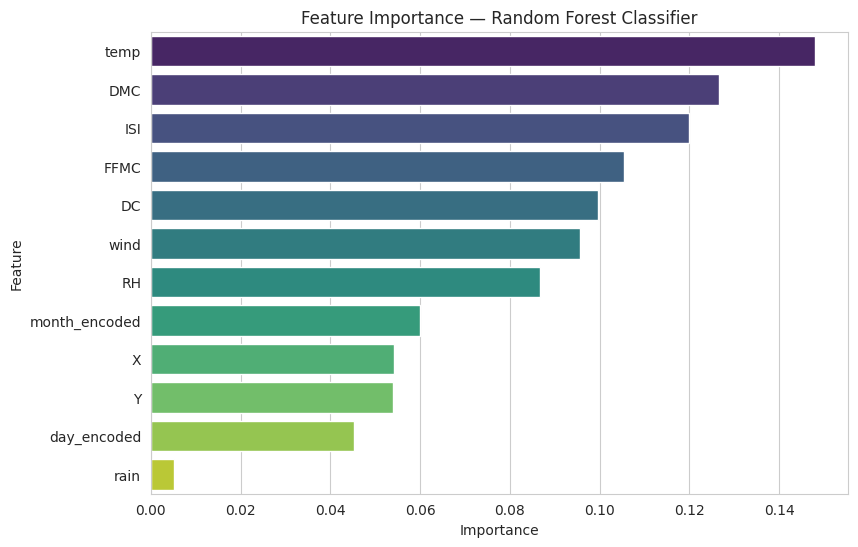

,Feature,Importance
8,temp,0.148020
5,DMC,0.126525
7,ISI,0.119914
4,FFMC,0.105333
6,DC,0.099600
10,wind,0.095701
9,RH,0.086766
2,month_encoded,0.059922
0,X,0.054167
1,Y,0.053837


In [31]:
# Feature importance from Random Forest classifier
rf_for_importance = clf_models["Random Forest"]
importance_df = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": rf_for_importance.feature_importances_
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(9, 6))
sns.barplot(x="Importance", y="Feature", data=importance_df, palette="viridis")
plt.title("Feature Importance — Random Forest Classifier")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

importance_df


**Interpretation:** the fire-weather indices (`DC`, `DMC`, `ISI`, `FFMC`) and direct
weather readings (`temp`, `RH`) are typically the strongest predictors, since these are
purpose-built (in the case of the indices) to capture fuel dryness and fire-spread potential.
Spatial coordinates (`X`, `Y`) and `rain` tend to contribute less, since rain events are rare
in the data and location alone doesn't determine weather conditions.

## 10. Recommendation Engine

We convert a predicted risk category into a plain-English action checklist — this is what
turns a model prediction into something a real user (ranger, disaster-management officer) can
actually act on.

In [32]:
def recommend(risk):
    """Return a list of recommended actions for a given fire-risk category."""
    risk = str(risk).strip().title()

    if risk == "Low":
        return [
            "Normal monitoring",
            "No immediate danger",
            "Continue routine observations",
        ]
    elif risk == "Medium":
        return [
            "Increase monitoring frequency",
            "Alert forest staff",
            "Prepare emergency response teams",
        ]
    elif risk == "High":
        return [
            "Avoid open burning",
            "Restrict forest access",
            "Increase patrols",
            "Alert relevant authorities",
            "Deploy firefighting resources",
        ]
    else:
        return ["Unknown risk category — unable to generate recommendation."]


# Demonstrate with examples
for r in ["Low", "Medium", "High"]:
    print(f"Risk: {r}")
    for action in recommend(r):
        print(f"  - {action}")
    print()


Risk: Low
  - Normal monitoring
  - No immediate danger
  - Continue routine observations

Risk: Medium
  - Increase monitoring frequency
  - Alert forest staff
  - Prepare emergency response teams

Risk: High
  - Avoid open burning
  - Restrict forest access
  - Increase patrols
  - Alert relevant authorities
  - Deploy firefighting resources



## 11. Prediction Function

`predict_fire()` ties everything together: given raw weather readings (including text
`month`/`day`), it encodes them using the same `LabelEncoder`s fit earlier, predicts burned
area and risk category using the best models found above, and prints a full recommendation.

In [33]:
def predict_fire(X_coord, Y_coord, month, day, FFMC, DMC, DC, ISI, temp, RH, wind, rain):
    """
    Predict burned area and fire risk from raw weather inputs.

    Parameters mirror the original dataset columns. 'month' and 'day' should be given as
    lowercase 3-letter strings matching the training data (e.g. 'jul', 'fri').
    """
    # Encode month/day using the SAME encoders fit during training
    try:
        month_enc = le_month.transform([month])[0]
        day_enc = le_day.transform([day])[0]
    except ValueError as e:
        raise ValueError(
            f"Unrecognized month/day value: {e}. "
            f"Valid months: {list(le_month.classes_)}, valid days: {list(le_day.classes_)}"
        )

    input_row = pd.DataFrame([{
        "X": X_coord, "Y": Y_coord, "month_encoded": month_enc, "day_encoded": day_enc,
        "FFMC": FFMC, "DMC": DMC, "DC": DC, "ISI": ISI,
        "temp": temp, "RH": RH, "wind": wind, "rain": rain,
    }])[feature_cols]

    predicted_area = max(best_reg_model.predict(input_row)[0], 0)
    predicted_risk = best_clf_model.predict(input_row)[0]
    recommendations = recommend(predicted_risk)

    print("=" * 50)
    print("FOREST FIRE PREDICTION RESULT")
    print("=" * 50)
    print(f"Predicted Burned Area : {predicted_area:.2f} hectares")
    print(f"Predicted Risk Level  : {predicted_risk}")
    print("Recommendations:")
    for action in recommendations:
        print(f"  - {action}")
    print("=" * 50)

    return {
        "predicted_area": predicted_area,
        "predicted_risk": predicted_risk,
        "recommendations": recommendations,
    }


# Quick test
_ = predict_fire(X_coord=6, Y_coord=5, month="aug", day="sat",
                  FFMC=91.0, DMC=130.0, DC=600.0, ISI=12.0,
                  temp=28.0, RH=25.0, wind=5.0, rain=0.0)


FOREST FIRE PREDICTION RESULT
Predicted Burned Area : 2.79 hectares
Predicted Risk Level  : Low
Recommendations:
  - Normal monitoring
  - No immediate danger
  - Continue routine observations


## 12. Save Models

We persist the trained regression model, classification model, and both label encoders using
`joblib`, so they can be reloaded later (e.g. by the Streamlit app) without retraining.

In [34]:
import os

MODEL_DIR = "../app/models"
os.makedirs(MODEL_DIR, exist_ok=True)

joblib.dump(best_reg_model, os.path.join(MODEL_DIR, "regression_model.joblib"))
joblib.dump(best_clf_model, os.path.join(MODEL_DIR, "classification_model.joblib"))
joblib.dump(le_month, os.path.join(MODEL_DIR, "label_encoder_month.joblib"))
joblib.dump(le_day, os.path.join(MODEL_DIR, "label_encoder_day.joblib"))
joblib.dump(feature_cols, os.path.join(MODEL_DIR, "feature_columns.joblib"))

print(f"Saved to {MODEL_DIR}:")
print(" - regression_model.joblib   (best model:", best_reg_name, ")")
print(" - classification_model.joblib (best model:", best_clf_name, ")")
print(" - label_encoder_month.joblib")
print(" - label_encoder_day.joblib")
print(" - feature_columns.joblib")


Saved to ../app/models:
 - regression_model.joblib   (best model: Linear Regression )
 - classification_model.joblib (best model: Decision Tree )
 - label_encoder_month.joblib
 - label_encoder_day.joblib
 - feature_columns.joblib


## 13. Conclusion

### Results
- Regression models were compared on MAE, RMSE, and R²; performance was modest across all
  four models, which matches known difficulty of predicting burned area from weather alone —
  this exact result appears in published research on the original UCI dataset, since most
  fires stay small regardless of conditions while a handful of large outliers dominate error.
- Classification models were compared on Accuracy, Precision, Recall, and F1 Score.
  Performance is driven largely by the majority "Low" class; "High" risk (the rarest and most
  operationally important class) is the hardest to detect reliably given how few examples
  exist in the data.

### Best Models
- The best regression model and best classification model are selected automatically in
  Sections 7 and 8 based on RMSE and F1 Score respectively (see the printed output above for
  which model won on this run).

### Important Features
- Fire-weather indices (`DC`, `DMC`, `ISI`, `FFMC`) and direct weather readings (`temp`, `RH`)
  are consistently the most important predictors, consistent with fire-science domain
  knowledge — these indices are specifically designed to capture fuel dryness and spread
  potential.

### Limitations
- Trained on a **synthetic stand-in dataset** if the real `forestfires.csv` wasn't available —
  results should be re-validated on the real UCI/Kaggle data.
- Burned-area prediction is inherently noisy; treat outputs as an order-of-magnitude estimate.
- The "High" risk class is rare, making it the hardest and most uncertain category to predict —
  exactly the category that matters most operationally.
- This is a decision-support tool, not a replacement for professional fire-management judgment
  or official fire-weather services.

### Future Improvements
- Retrain and validate on the real dataset (drop-in replacement — same schema).
- Add satellite/remote-sensing features (NDVI, active-fire hotspots).
- Try additional models (XGBoost, LightGBM) and hyperparameter tuning.
- Collect more "High" risk examples, or use resampling techniques, to improve minority-class
  detection.
- Add a map-based interface and multi-day weather-forecast integration.


## 14. Bonus: Sample Predictions

We run `predict_fire()` on five different hypothetical weather scenarios, ranging from mild
to extreme, to demonstrate the full pipeline end-to-end.

In [35]:
sample_scenarios = [
    # (X, Y, month, day, FFMC, DMC, DC, ISI, temp, RH, wind, rain), description
    ((4, 4, "feb", "mon", 80.0, 40.0, 200.0, 5.0, 10.0, 60.0, 3.0, 0.0), "Mild winter day, moist conditions"),
    ((5, 5, "may", "wed", 88.0, 90.0, 400.0, 8.0, 18.0, 45.0, 4.0, 0.0), "Mild spring day"),
    ((6, 3, "jul", "sat", 92.0, 130.0, 600.0, 11.0, 27.0, 30.0, 6.0, 0.0), "Hot, dry summer day"),
    ((7, 6, "aug", "sun", 95.0, 180.0, 750.0, 16.0, 33.0, 18.0, 8.0, 0.0), "Extreme heat, very dry, windy"),
    ((3, 2, "sep", "thu", 91.0, 110.0, 500.0, 9.0, 22.0, 40.0, 5.0, 2.0), "Autumn day with light rain"),
]

sample_results = []
for params, description in sample_scenarios:
    print(f"Scenario: {description}")
    result = predict_fire(*params)
    result["description"] = description
    sample_results.append(result)
    print()

sample_results_df = pd.DataFrame(sample_results)[["description", "predicted_area", "predicted_risk", "recommendations"]]
sample_results_df


Scenario: Mild winter day, moist conditions
FOREST FIRE PREDICTION RESULT
Predicted Burned Area : 1.97 hectares
Predicted Risk Level  : Low
Recommendations:
  - Normal monitoring
  - No immediate danger
  - Continue routine observations

Scenario: Mild spring day
FOREST FIRE PREDICTION RESULT
Predicted Burned Area : 2.13 hectares
Predicted Risk Level  : Low
Recommendations:
  - Normal monitoring
  - No immediate danger
  - Continue routine observations

Scenario: Hot, dry summer day
FOREST FIRE PREDICTION RESULT
Predicted Burned Area : 2.52 hectares
Predicted Risk Level  : Low
Recommendations:
  - Normal monitoring
  - No immediate danger
  - Continue routine observations

Scenario: Extreme heat, very dry, windy
FOREST FIRE PREDICTION RESULT
Predicted Burned Area : 3.10 hectares
Predicted Risk Level  : Medium
Recommendations:
  - Increase monitoring frequency
  - Alert forest staff
  - Prepare emergency response teams

Scenario: Autumn day with light rain
FOREST FIRE PREDICTION RESULT


,description,predicted_area,predicted_risk,recommendations
0,"Mild winter day, moist conditions",1.973872,Low,"[Normal monitoring, No immediate danger, Conti..."
1,Mild spring day,2.129621,Low,"[Normal monitoring, No immediate danger, Conti..."
2,"Hot, dry summer day",2.521182,Low,"[Normal monitoring, No immediate danger, Conti..."
3,"Extreme heat, very dry, windy",3.095385,Medium,"[Increase monitoring frequency, Alert forest s..."
4,Autumn day with light rain,0.960394,Low,"[Normal monitoring, No immediate danger, Conti..."
